In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [8]:
def load_coerece(experiment):
    folder = f"results/wigner_{experiment}"
    t = np.load(os.path.join(folder, "t.npy"))

    if experiment in ['cos1', 'cos2','cos3',"cos5",'linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6', "cos_mod1"]:
        list = np.load(os.path.join(folder, "w_list.npy"))
    elif experiment in ['gauss1',  'gauss4','gauss5', "gauss_mod1",  "gauss_mod2"]:
        list = np.load(os.path.join(folder, "ep_list.npy")) 
    elif experiment in ['gauss3','gauss2','gauss6']:
        list = np.load(os.path.join(folder, "T_list.npy"))
    elif experiment in ['cos4']:
        list = np.load(os.path.join(folder, 'phi_list.npy'))

    var_aberto = np.load(os.path.join(folder, "var_aberto.npy"), allow_pickle=True)
    const_aberto = np.load(os.path.join(folder, "const_aberto.npy"), allow_pickle=True)

    C_wt = np.vstack([np.asarray(row, dtype=np.complex128).ravel() for row in var_aberto])
    C_wt = np.real(C_wt)  # coherence should be real; keep real part safely

    const_aberto = np.asarray(const_aberto, dtype=np.complex128).ravel()
    const_aberto = np.real(const_aberto)

    # Difference: var_aberto(w,t) - const_aberto(t)
    D_wt = C_wt - const_aberto[None, :]
    return list, C_wt, D_wt, const_aberto, t


# --- MINIMAL ADD: centers -> edges (for non-uniform spacing) ---
def _edges_from_centers(x):
    x = np.asarray(x)
    dx = np.diff(x)
    edges = np.empty(x.size + 1, dtype=x.dtype)
    edges[1:-1] = x[:-1] + dx / 2
    edges[0] = x[0] - dx[0] / 2
    edges[-1] = x[-1] + dx[-1] / 2
    return edges


def plot_coherence_and_difference(
    t,
    list,
    C_wt,
    D_wt,
    cmap_var=None,
    cmap_diff=None,
    experiment="linear1"
):

    # --- MINIMAL ADD: edges for non-uniform t/list ---
    t_edges = _edges_from_centers(t)
    list_edges = _edges_from_centers(list)

    # ==========================
    # Plot 1: Coerência
    # ==========================
    plt.figure()
    plt.pcolormesh(
        t_edges, list_edges, C_wt,
        shading="auto",
        cmap=cmap_var
    )
    plt.xlabel("$t$",fontsize=20)

    if experiment in ['cos1', 'cos2', 'cos3', 'linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        plt.ylabel(r"$\omega$",fontsize=20)
    elif experiment in ['gauss1', 'gauss2', 'gauss4', 'gauss5']:
        plt.ylabel(r"$\zeta$",fontsize=20)
    elif experiment in ['gauss3','gauss6']:
        plt.ylabel(r"$T$",fontsize=20)
    elif experiment in ['cos4']:
        plt.ylabel(r'$\phi$', fontsize=20)

    plt.colorbar(label=r"$C(\rho^{(Q)})$")
    plt.tight_layout()
    plt.show()

    # ==========================
    # Plot 2: Diferença
    # ==========================
    plt.figure()
    plt.pcolormesh(
        t_edges, list_edges, D_wt,
        shading="auto",
        cmap=cmap_diff
    )
    plt.xlabel("t",fontsize=20)

    if experiment in ['linear1', 'linear2', 'linear3', 'linear4', 'linear5', 'linear6',
                      'exp1', 'exp2', 'exp3', 'exp4', 'exp5', 'exp6']:
        plt.ylabel(r"$\omega$", fontsize=20)
    elif experiment in ['gauss1', 'gauss2', 'gauss4', 'gauss5']:
        plt.ylabel(r"$\zeta$", fontsize=20)
    elif experiment in ['gauss3','gauss6']:
        plt.ylabel(r"$T$", fontsize=20)
    elif experiment in ['cos4']:
        plt.ylabel(r'$\phi$', fontsize=20)

    plt.colorbar(label=r"$\Delta C(\rho^{(Q)})$")
    plt.tight_layout()
    plt.show()


def plot_selected_coherences(
    t,
    const,
    C_wt,
    list,
    indices,
    scale_factor=1e-3,
    yscale="log"
):
    plt.figure()

    # curva constante
    plt.plot(t, const, label=r"$g_0$")

    # curvas selecionadas
    for i in indices:
        d_val = list[i]**2 / scale_factor
        label = rf"$g_t$ with $d={d_val:.5g}$"
        plt.plot(t, C_wt[i])

    #plt.yscale(yscale)
    plt.xlabel("$t$", fontsize=20)
    plt.ylabel(r"$C(\rho^{Q})$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1. Gaussiana
Vamos considerar a modulação do tipo gaussiana,

\begin{equation}
    g(t) = g_0 \exp\left[\frac{\sigma(t-T)^2}{\zeta^2}\right],
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 1.1 Pico no meio e variando a espessura do pico
Aqui, vamos verifical tal comportamento fazendo $\sigma=-1$ e $6/(50/15) < \zeta < 10/(50/15)$, com $T=7.5$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_6314/3097268734.py:7: S

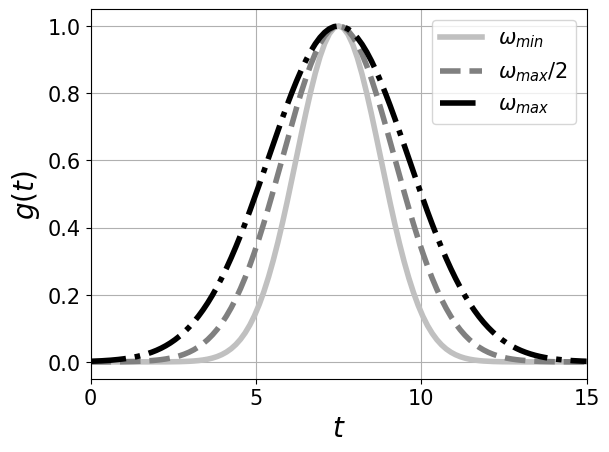

In [9]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss4')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-7.5)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10, 15], fontsize=15)
plt.xlim(0, 15)
plt.grid(True)
plt.show()

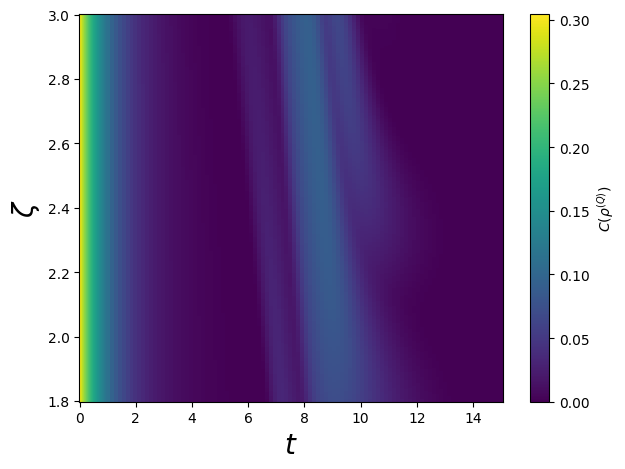

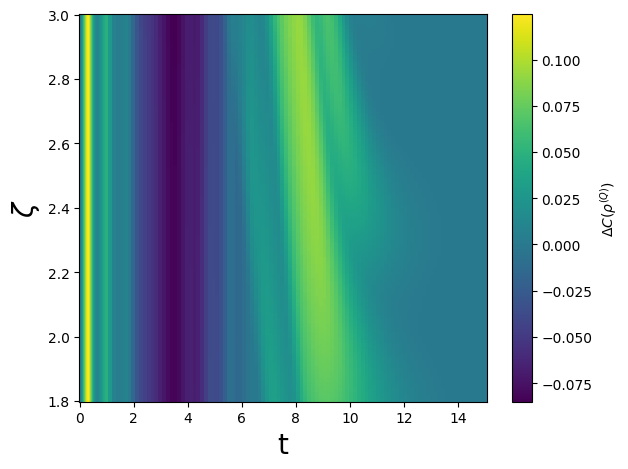

In [10]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss4')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss4'
)

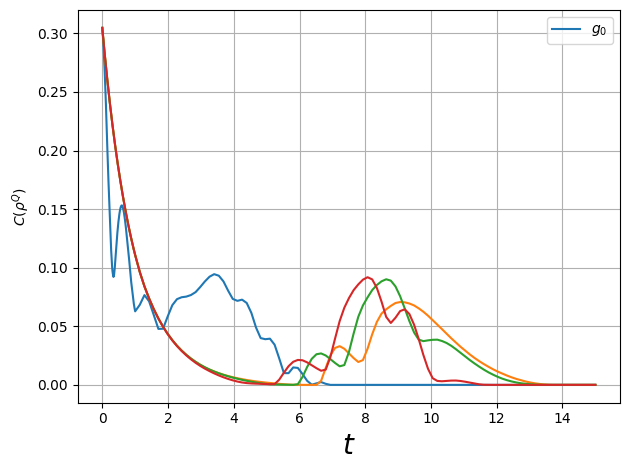

In [11]:
plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


## 1.2 - Variando T

$\zeta = 8/(50/15)$ and $35/(50/15) \leq T \leq 50/(50/15)$




<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_6314/1501822345.py:7: S

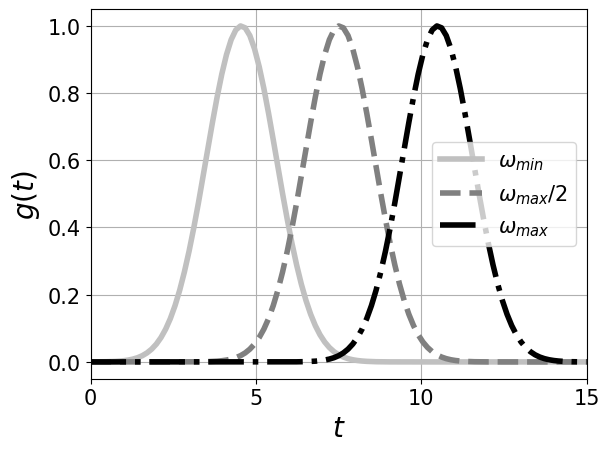

In [12]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss6')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-w_list[idx])**2/1.5**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10, 15], fontsize=15)
plt.xlim(0, 15)
plt.grid(True)
plt.show()

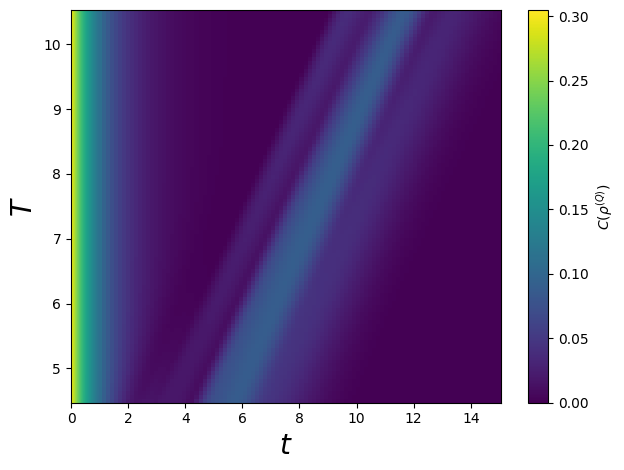

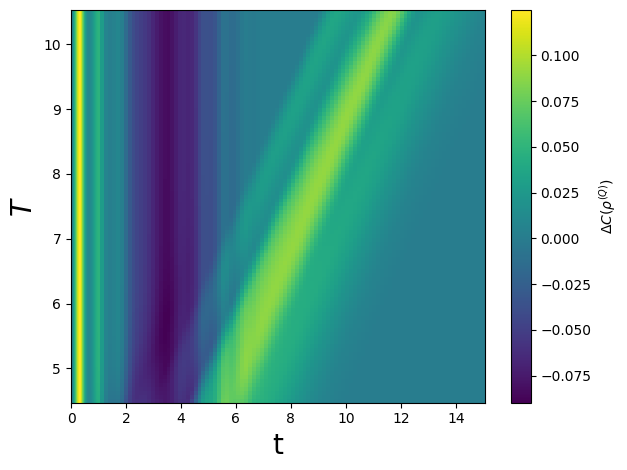

In [13]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss6')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss6'
)

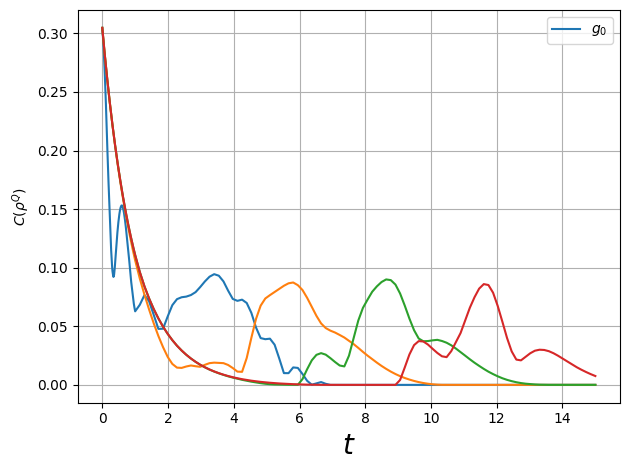

In [14]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


## 1.3 - Gauss 2 T

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_6314/2586148570.py:7: S

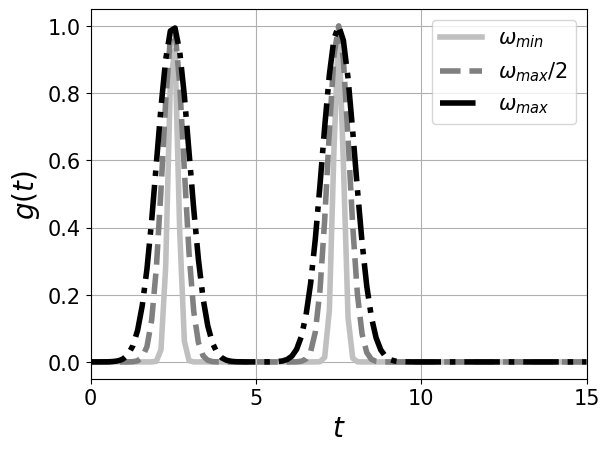

In [15]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss_mod2')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-7.5)**2/w_list[idx]**2) +  np.exp(-(t-2.5)**2/w_list[idx]**2)
    #g =  np.exp(-((t - 2.5)/w_list[idx]**2)) +  np.exp(-((t - 7.5)/w_list[idx]**2))
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10, 15], fontsize=15)
plt.xlim(0, 15)
plt.grid(True)
plt.show()

In [16]:
w_list

array([0.2       , 0.20251256, 0.20502513, 0.20753769, 0.21005025,
       0.21256281, 0.21507538, 0.21758794, 0.2201005 , 0.22261307,
       0.22512563, 0.22763819, 0.23015075, 0.23266332, 0.23517588,
       0.23768844, 0.24020101, 0.24271357, 0.24522613, 0.24773869,
       0.25025126, 0.25276382, 0.25527638, 0.25778894, 0.26030151,
       0.26281407, 0.26532663, 0.2678392 , 0.27035176, 0.27286432,
       0.27537688, 0.27788945, 0.28040201, 0.28291457, 0.28542714,
       0.2879397 , 0.29045226, 0.29296482, 0.29547739, 0.29798995,
       0.30050251, 0.30301508, 0.30552764, 0.3080402 , 0.31055276,
       0.31306533, 0.31557789, 0.31809045, 0.32060302, 0.32311558,
       0.32562814, 0.3281407 , 0.33065327, 0.33316583, 0.33567839,
       0.33819095, 0.34070352, 0.34321608, 0.34572864, 0.34824121,
       0.35075377, 0.35326633, 0.35577889, 0.35829146, 0.36080402,
       0.36331658, 0.36582915, 0.36834171, 0.37085427, 0.37336683,
       0.3758794 , 0.37839196, 0.38090452, 0.38341709, 0.38592

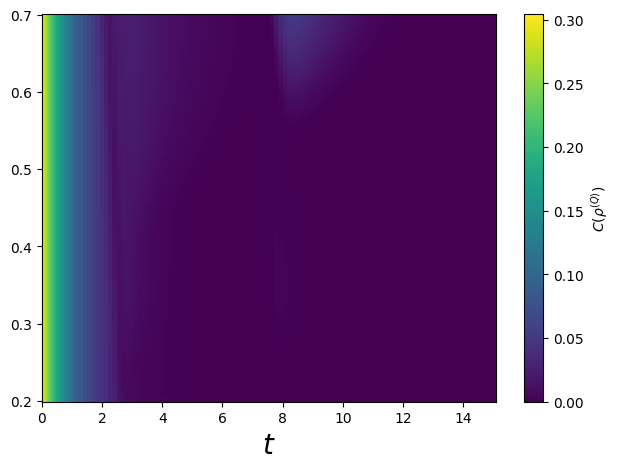

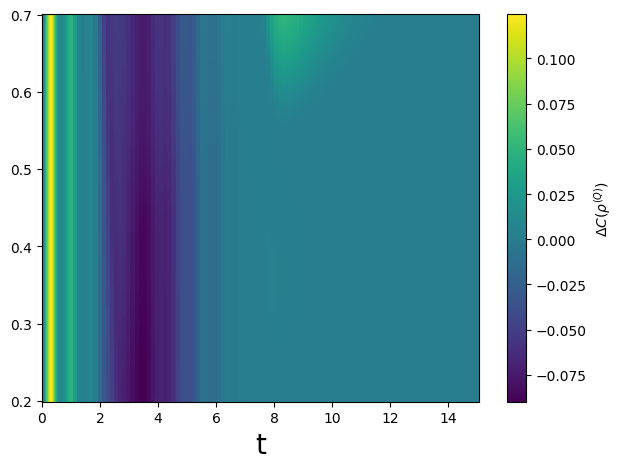

In [17]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss_mod2')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss_mod2'
)

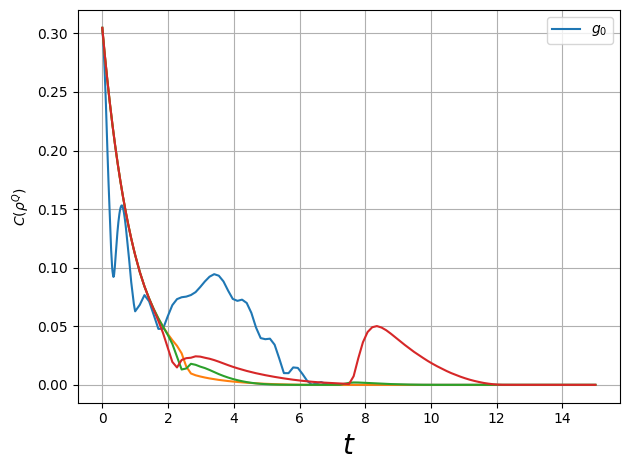

In [18]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -2]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


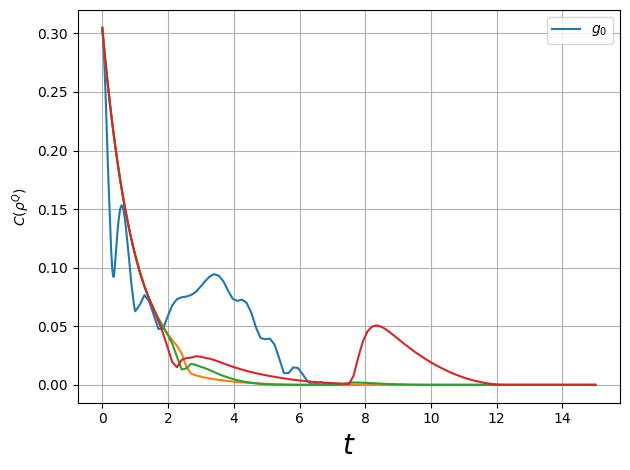

In [19]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


# 4. Trigonométricas

Vamos considerar a modulação do tipo,

\begin{equation}
    g(t) = g_0 \cos(\omega t + \phi),
\end{equation}
mas modificando os tais parâmetros para compreender diferentes cenários físicos.

## 4.1 Cosseno
Aqui, vamos verifical tal comportamento fazendo $\phi=0$, $0 < \omega< ((50/15)* \pi)/5$ e $0<t<15$.

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_6314/69084308.py:7: Syn

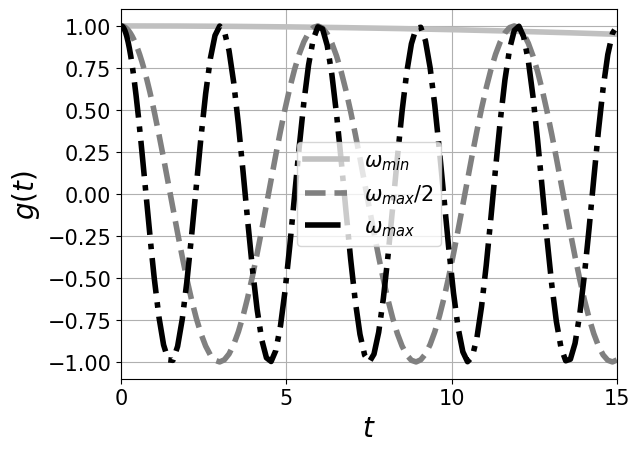

In [20]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.cos(w_list[idx]*t)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10, 15], fontsize=15)
plt.xlim(0, 15)
plt.grid(True)
plt.show()

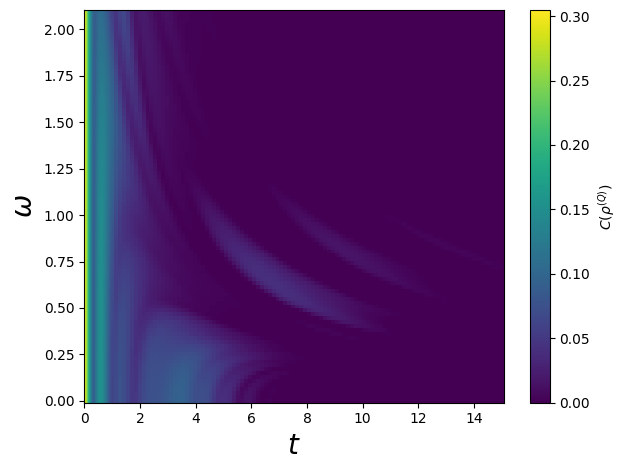

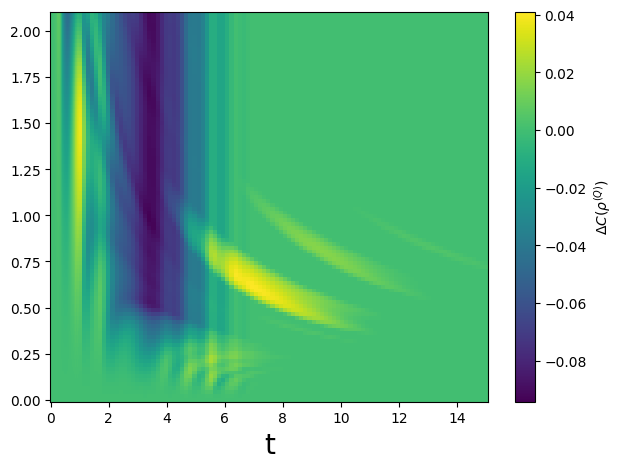

In [21]:
w_list, C_wt, D_wt, const, t = load_coerece('cos1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='cos1'
)

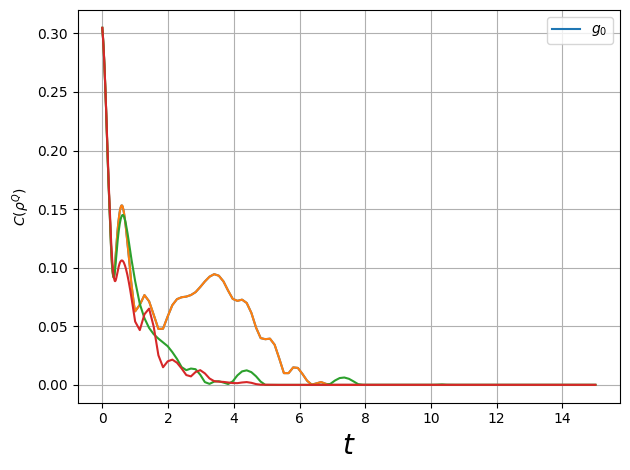

In [22]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)


# NOVO


<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ds/vr9pfb552rqfjz20kskk9g7m0000gn/T/ipykernel_6314/1772917724.py:7: S

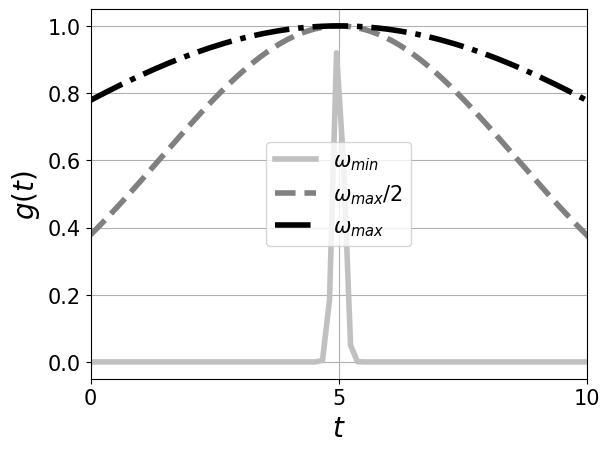

In [23]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

lw_list = ['-', '--', '-.']
c_list = ['silver', 'gray','black']
indices = [1, len(w_list)//2, -1]

w_label = ['$\omega_{min}$','$\omega_{max}$/2','$\omega_{max}$']
# NÃO ESTÁ FINALIZADO
for i, idx in enumerate(indices):
    g = np.exp(-(t-5)**2/w_list[idx]**2)
    plt.plot(t, g, lw=4, ls=lw_list[i], color=c_list[i], label=w_label[i])


plt.legend(fontsize=15)
plt.ylabel('$g(t)$', fontsize=20)
plt.xlabel('$t$', fontsize=20)
#plt.yscale('log')
plt.yticks(fontsize=15)
plt.xticks([0, 5, 10,], fontsize=15)
plt.xlim(0, 10)
plt.grid(True)
plt.show()

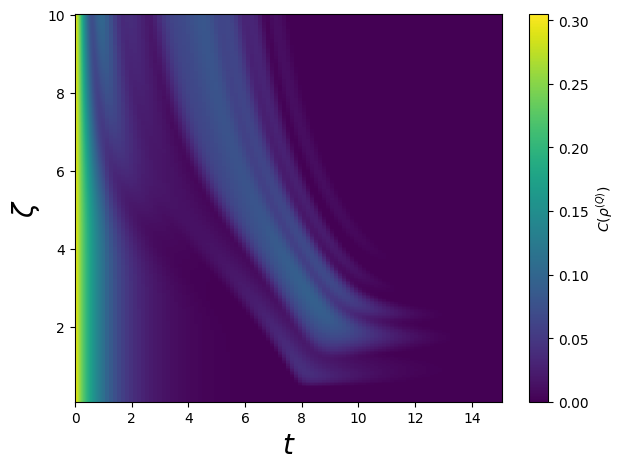

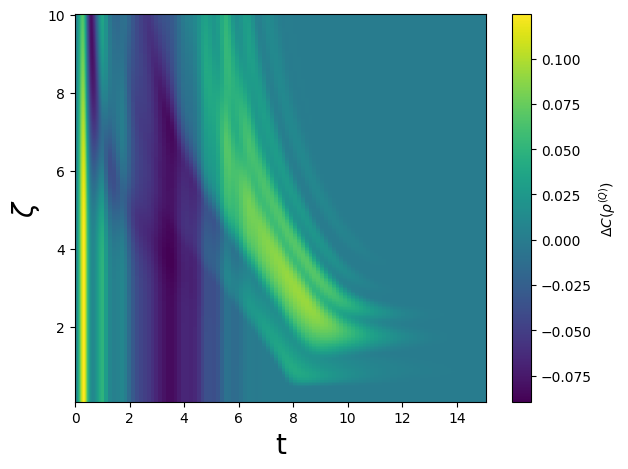

In [24]:
w_list, C_wt, D_wt, const, t = load_coerece('gauss1')

plot_coherence_and_difference(
    t=t,
    list=w_list,
    C_wt=C_wt,
    D_wt=D_wt,
    experiment='gauss1'
)

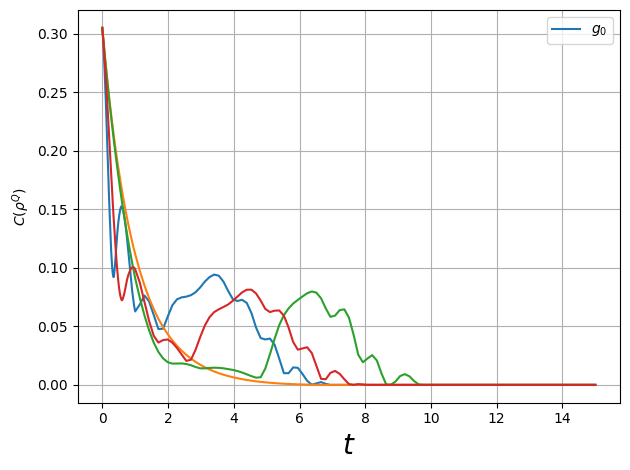

In [25]:
# Aqui não sei como ver essa variação, então só vou plotar primeiro, meio e ultimo. ignore o d no gráfico
indices = [0, len(w_list)//2, -1]

plot_selected_coherences(
    t=t,
    const=const,
    C_wt=C_wt,
    list=w_list,
    indices=indices,
)
